In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("../data/kickstarter_us_filtered.csv")


In [7]:
df.groupby("status")[["updates", "comments"]].describe()

updates                                                comments  \
              count      mean       std  min  25%  50%  75%    max    count   
status                                                                        
failed      17429.0  1.479201  3.228073  0.0  0.0  0.0  2.0   83.0  17429.0   
successful  21075.0  6.610059  7.600497  0.0  2.0  5.0  9.0  149.0  21075.0   

                                                                
                 mean         std  min  25%  50%  75%      max  
status                                                          
failed       0.939182    4.944084  0.0  0.0  0.0  1.0    442.0  
successful  14.825148  246.721997  0.0  0.0  2.0  6.0  19311.0

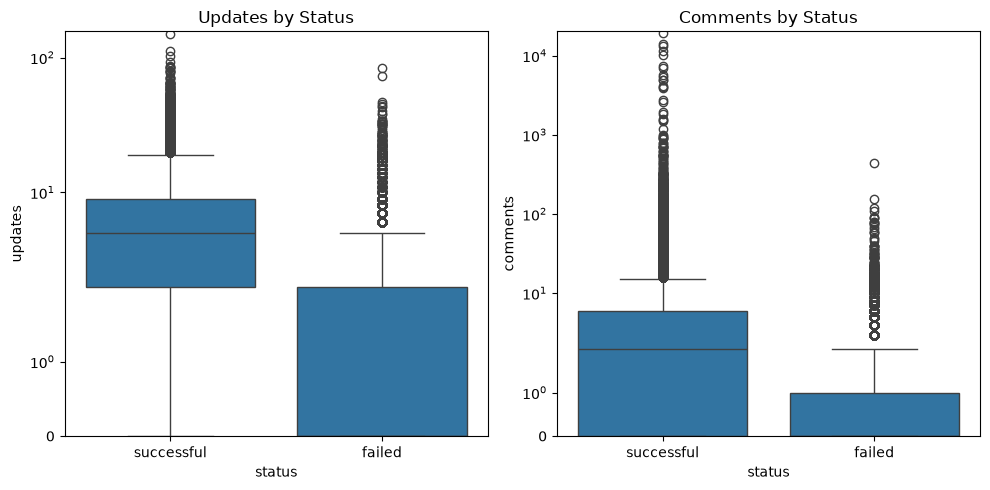

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.boxplot(x="status", y="updates", data=df, ax=axes[0])
sns.boxplot(x="status", y="comments", data=df, ax=axes[1])
axes[0].set_title("Updates by Status")
axes[1].set_title("Comments by Status")
axes[0].set_yscale("symlog")
axes[1].set_yscale("symlog")
axes[0].set_ylim(bottom=0)
axes[1].set_ylim(bottom=0)
plt.tight_layout()
plt.show()

# The median for failed campaigns is 0 for both columns.


In [14]:
df["status_binary"] = (df["status"] == "successful").astype(int)

engagement = df[["updates", "comments", "status_binary"]]
print("Pearson:")
print(engagement.corr())
print("\nSpearman:")
print(engagement.corr(method="spearman"))

Pearson:
                updates  comments  status_binary
updates        1.000000  0.102234       0.390119
comments       0.102234  1.000000       0.037834
status_binary  0.390119  0.037834       1.000000

Spearman:
                updates  comments  status_binary
updates        1.000000  0.543109       0.552169
comments       0.543109  1.000000       0.468644
status_binary  0.552169  0.468644       1.000000


## Findings: Updates and Comments vs. Success

**Group comparison.** Successful campaigns had far more engagement than failed ones. The median number of updates was 5 for successful campaigns vs. 0 for failed ones, and the median number of comments was 2 vs. 0. The groups barely overlap on updates: the 75th percentile for failed campaigns (2) equals the 25th percentile for successful ones (2). Both columns are heavily right-skewed (for example, one campaign has 19,311 comments), so medians are more reliable than means.

**Correlation.** Updates show a moderate-to-strong association with success (Pearson 0.39, Spearman 0.55). Comments appear almost unrelated under Pearson (0.04) but moderately related under Spearman (0.47). The difference is caused by extreme outliers, which distort Pearson but do not affect Spearman, which uses rankings, so Spearman is the more trustworthy measure for comments.

**Share with any engagement.** 88% of successful campaigns posted at least one update, vs. 42% of failed campaigns. For comments, it was 70% vs. 26%.

**Caveats.** These are associations, not causal effects. Updates and comments accumulate over a campaign's lifetime, and campaigns that are already succeeding tend to attract more of both. Because these counts are not known at launch, they may not be appropriate predictors for a model intended to forecast success at launch, which is a question for Milestone 3.